# Notebook 02: Exploratory Data Analysis on Smoothed Technical Features

This notebook covers **Chapter 3 (Exploratory Data Analysis)** 

Focus areas:
1. Statistical summary using full dataset structure (`pandas.info()` + descriptive tables).
2. Correlation analysis with next-day return label.
3. Trend and pattern discovery with rich visuals (histograms, box plots, time-series, scatter plots).


In [14]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.2f}".format)


In [15]:
CONFIG_PATH = Path("../data/processed/modeling_config.json")
cfg = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

data_csv = Path(cfg["data_csv"])
df = pd.read_csv(data_csv, index_col=0, parse_dates=True).sort_index()

feature_cols = cfg["feature_cols"]
target_col = cfg["target_col"]

print("Loaded target:", target_col)
print("Loaded training features:", feature_cols)

df.head()

Loaded target: target_close_1d
Loaded training features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14', 'volume']


,Adj Close,adj_close_smooth,target_ret_1d_pct,volume,rsi_14,macd_hist_12_26_9,adx_14,atr_14,obv,sma_10,ema_20,bb_bandwidth_20_2,target_close_1d
Date,,,,,,,,,,,,,
2016-06-03,22.31,22.41,0.73,142215825.77,53.54,0.27,53.55,2.35,-2360426223.85,22.17,22.22,10.36,22.47
2016-06-06,22.47,22.43,0.41,127502078.04,54.09,0.25,50.74,2.36,-2232924145.81,22.26,22.24,10.69,22.56
2016-06-07,22.56,22.47,-0.09,116142854.63,55.26,0.22,48.17,2.37,-2116781291.19,22.35,22.26,10.91,22.54
2016-06-08,22.54,22.49,0.72,106317718.24,55.93,0.20,45.79,2.37,-2010463572.95,22.42,22.28,11.03,22.71
2016-06-09,22.71,22.56,-0.82,106344082.77,57.86,0.18,43.66,2.38,-1904119490.18,22.47,22.31,11.04,22.52


## 1) Statistical Summary (Full Dataset Structure)

The assignment guideline asks for statistical summarization and clear dataset inspection. We therefore include:
- `df.info()` to show data types, non-null counts, and memory usage.
- Descriptive statistics for all numeric fields.


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2479 entries, 2016-06-03 to 2026-04-14
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Adj Close          2479 non-null   float64
 1   adj_close_smooth   2479 non-null   float64
 2   target_ret_1d_pct  2479 non-null   float64
 3   volume             2479 non-null   float64
 4   rsi_14             2479 non-null   float64
 5   macd_hist_12_26_9  2479 non-null   float64
 6   adx_14             2479 non-null   float64
 7   atr_14             2479 non-null   float64
 8   obv                2479 non-null   float64
 9   sma_10             2479 non-null   float64
 10  ema_20             2479 non-null   float64
 11  bb_bandwidth_20_2  2479 non-null   float64
 12  target_close_1d    2479 non-null   float64
dtypes: float64(13)
memory usage: 271.1 KB


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Adj Close,2479.00,122.17,75.02,20.97,44.90,128.35,177.33,285.92
adj_close_smooth,2479.00,121.95,74.91,21.44,44.93,128.20,176.81,281.27
target_ret_1d_pct,2479.00,0.12,1.82,-12.86,-0.71,0.11,0.99,15.33
volume,2479.00,97105786.94,45758896.89,28821944.40,61007603.66,89929883.41,120247430.07,334400167.18
rsi_14,2479.00,61.08,24.31,5.96,40.26,65.04,81.95,99.31
macd_hist_12_26_9,2479.00,-0.00,0.69,-2.71,-0.26,0.02,0.29,2.64
adx_14,2479.00,47.87,17.50,16.34,34.43,45.62,59.26,91.84
atr_14,2479.00,3.96,1.14,2.29,3.01,3.80,4.83,9.60
obv,2479.00,28459597522.44,14057190041.11,-3528221263.97,14721795508.33,35957733778.15,40039381361.79,45680435274.73
sma_10,2479.00,121.53,74.78,21.62,44.65,127.75,176.47,279.39


## 2) Feature Distribution Analysis (Histogram + Box Plot)

Each selected feature is visualized using:
- histogram (shape/distribution), and
- box plot (spread/outliers).

This helps assess scaling, heavy tails, and the selected indicator's behavior before modeling.


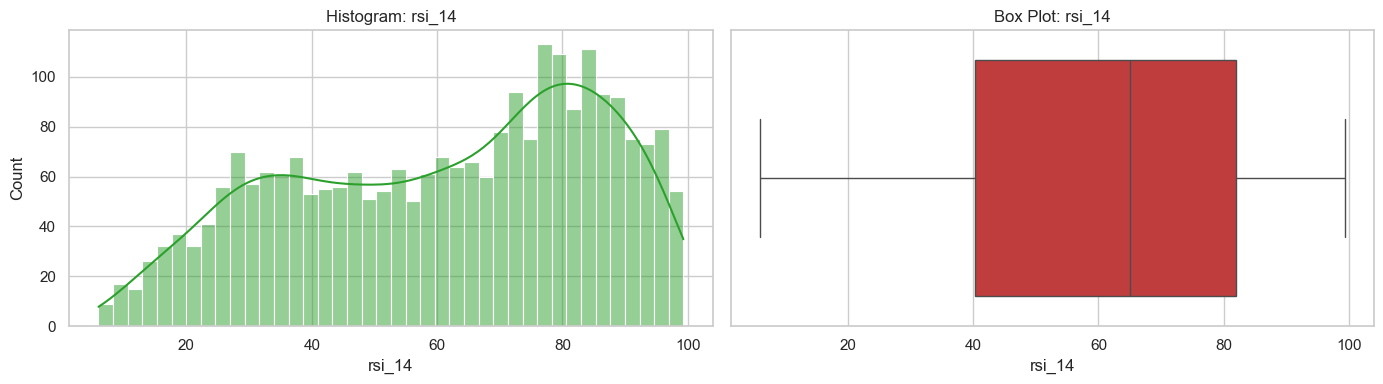

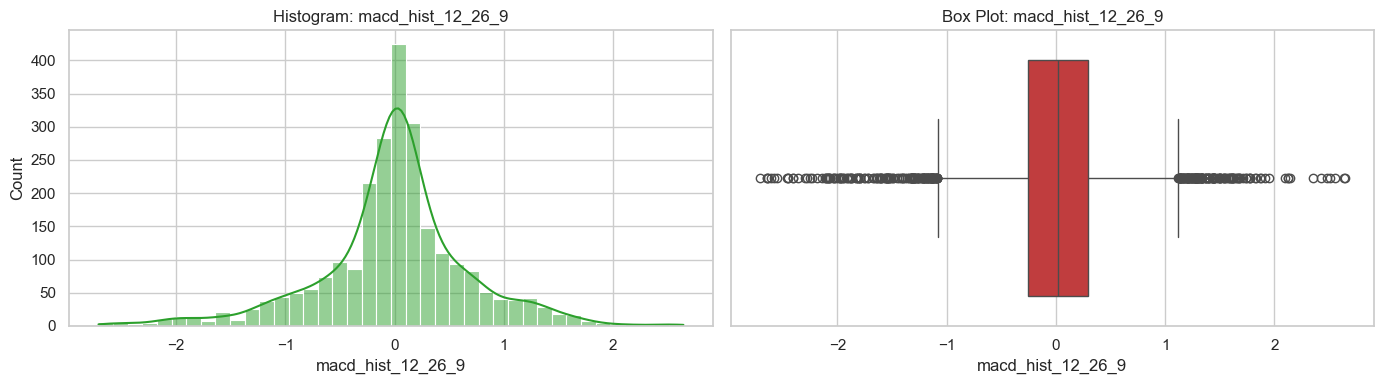

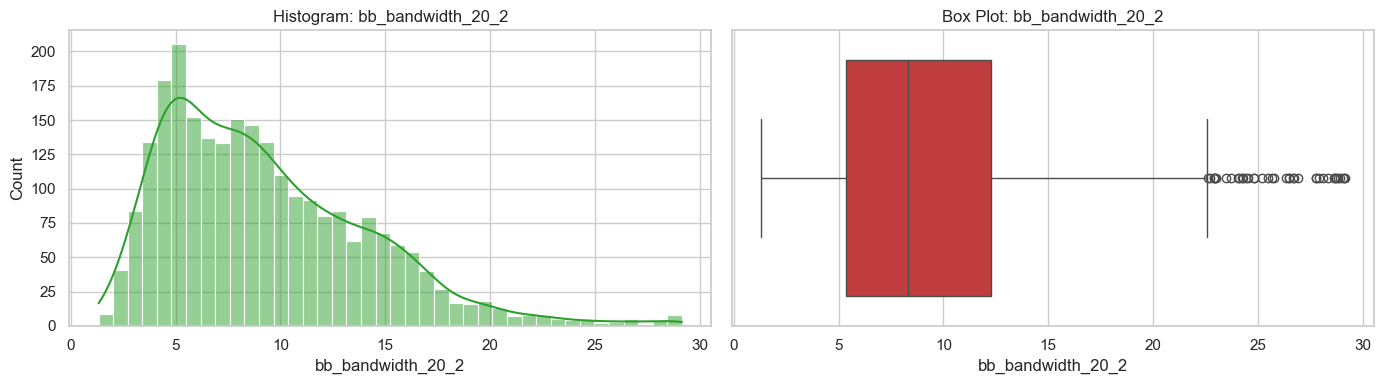

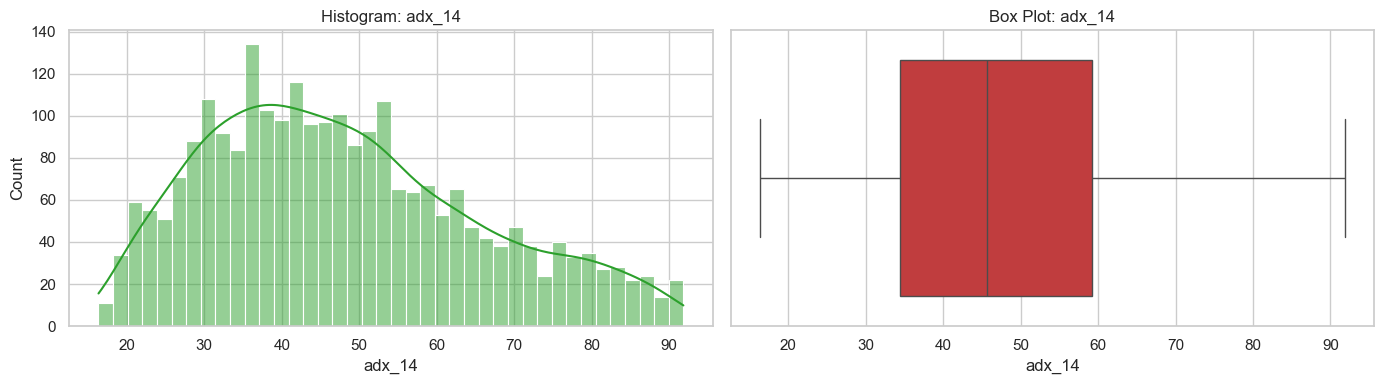

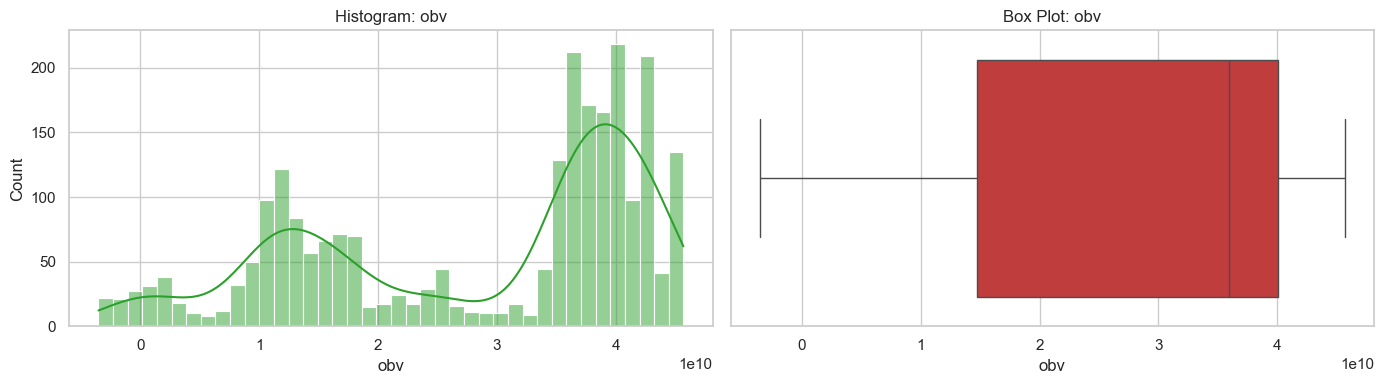

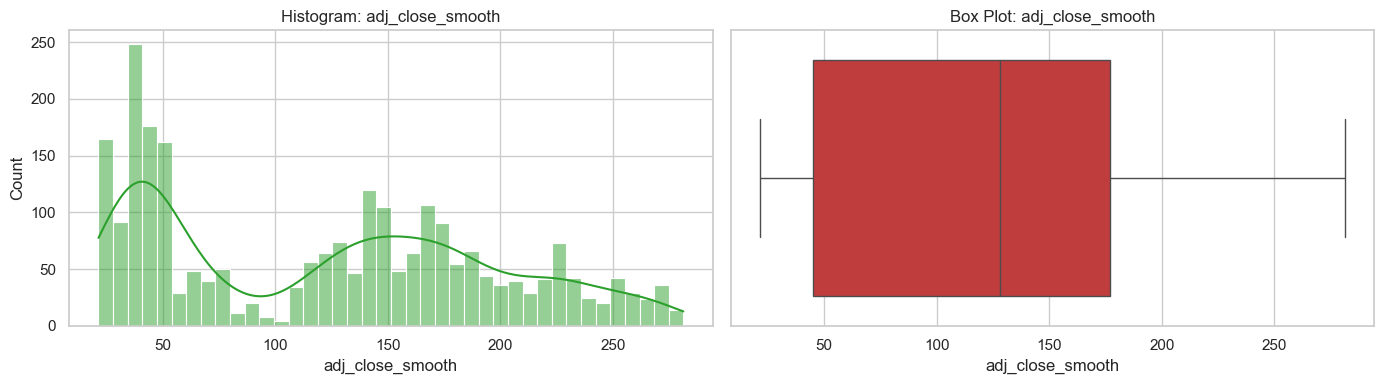

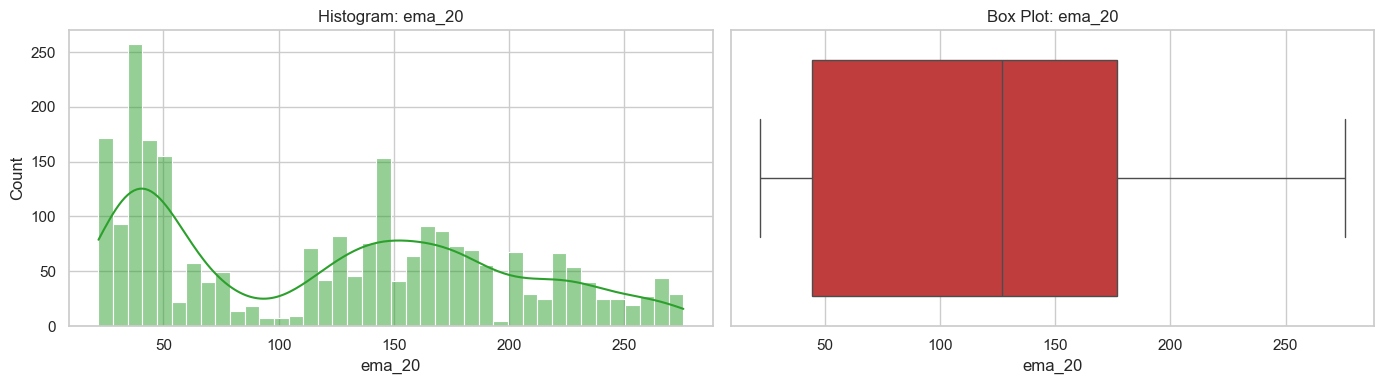

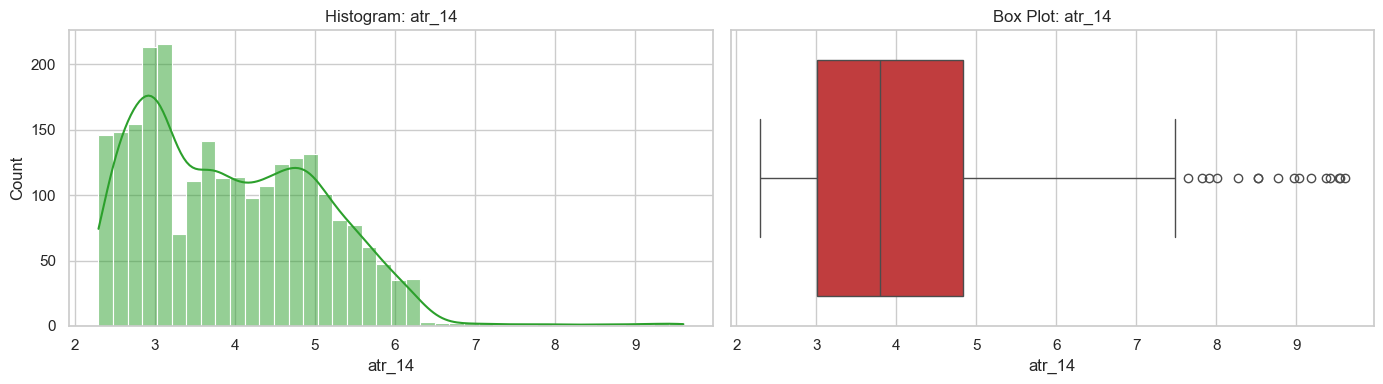

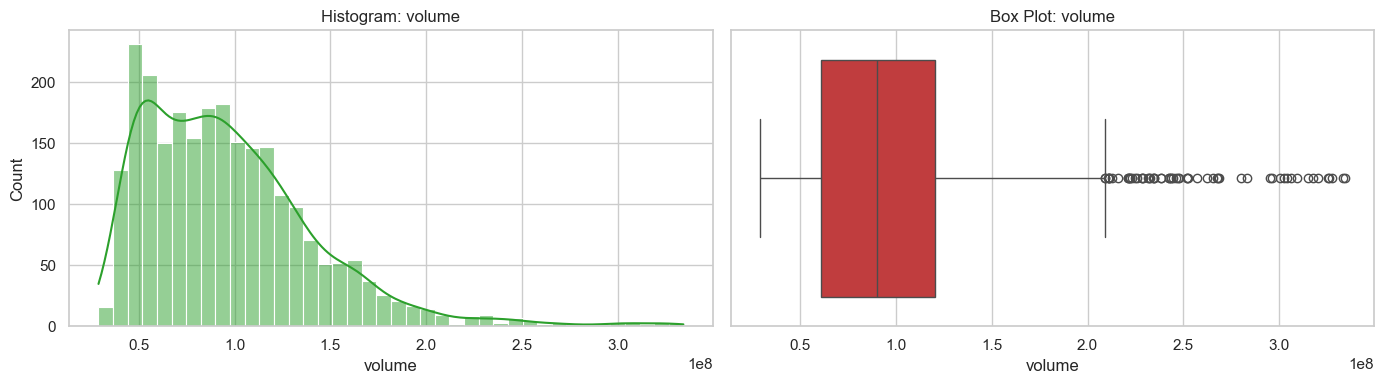

In [18]:
for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df[col], bins=40, kde=True, ax=axes[0], color="#2ca02c")
    axes[0].set_title(f"Histogram: {col}")
    axes[0].set_xlabel(col)

    sns.boxplot(x=df[col], ax=axes[1], color="#d62728")
    axes[1].set_title(f"Box Plot: {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

## 4) Correlation Analysis with Target


A feature-feature heatmap is also included to inspect remaining multicollinearity.  Even modest correlations are informative in finance, where signal-to-noise is usually low.

Moreover, the heatmap is used to identify redundant indicator pairs, which helps to  keep later regression models stable and interpretable by avoiding highly overlapping predictors.



In [19]:
pearson = df[feature_cols + [target_col]].corr(method="pearson")
pearson[target_col].drop(target_col).sort_values(ascending=False)

adj_close_smooth     1.00
ema_20               1.00
obv                  0.93
atr_14               0.68
macd_hist_12_26_9   -0.01
bb_bandwidth_20_2   -0.04
rsi_14              -0.10
adx_14              -0.18
volume              -0.66
Name: target_close_1d, dtype: float64

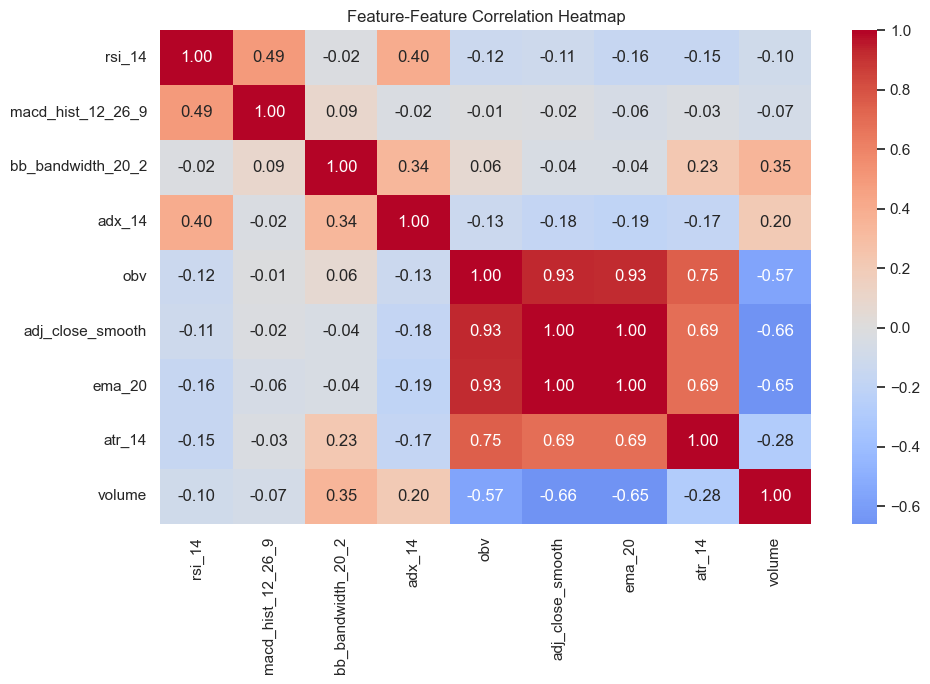

In [20]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature-Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5) Trend and Pattern Discovery

Visual trend analysis improves the quality of interpretation in the report. We examine:


In [21]:
# used to selectively show relevant recent data in EDA plots 
# to not overwhelm the visualizations with too much data
def trim(df, year=3):
    df.index = pd.to_datetime(df.index)
    end_date = df.index.max()
    start_date = end_date - pd.DateOffset(years=year)

    return df.loc[df.index >= start_date].copy()

### ADX Trend-Strength Visualization and Regime Summary

This section uses ADX(14) to interpret **trend strength** (non-directional) by shading price periods for weak vs extremely strong, and summarizing next-day return statistics by ADX strength buckets to evaluate how trend strength relates to subsequent returns. This is beneficial for us in predicting the next day's stock price.

**Insights**

When ADX < 25 (weak), the price is more likely in a choppy region, which is reflected by the lowest average return (mean -0.06%) and relatively limited upside (max 3.71%)—conditions where trend-following signals tend to underperform.

Then, as ADX moves into ≥25, returns improve. The 25–50 and 50–75 range have positive means (0.14%, 0.16%), and 50–75 also has a higher median (0.19%), consistent with more sustained trends. Plus, the price movement increases sharply. The 25–50 range shows the widest return range (min -9.25%, max 15.33%), indicating stronger but more volatile moves.

For ADX > 75, a plausible reason the min/max returns look comparatively low is that this regime often occurs **late in an established trend**, so the future price movement becomes relatively low. Plus, ADX can stay elevated even as momentum cools, so subsequent returns may revert toward smaller moves rather than extending explosively.


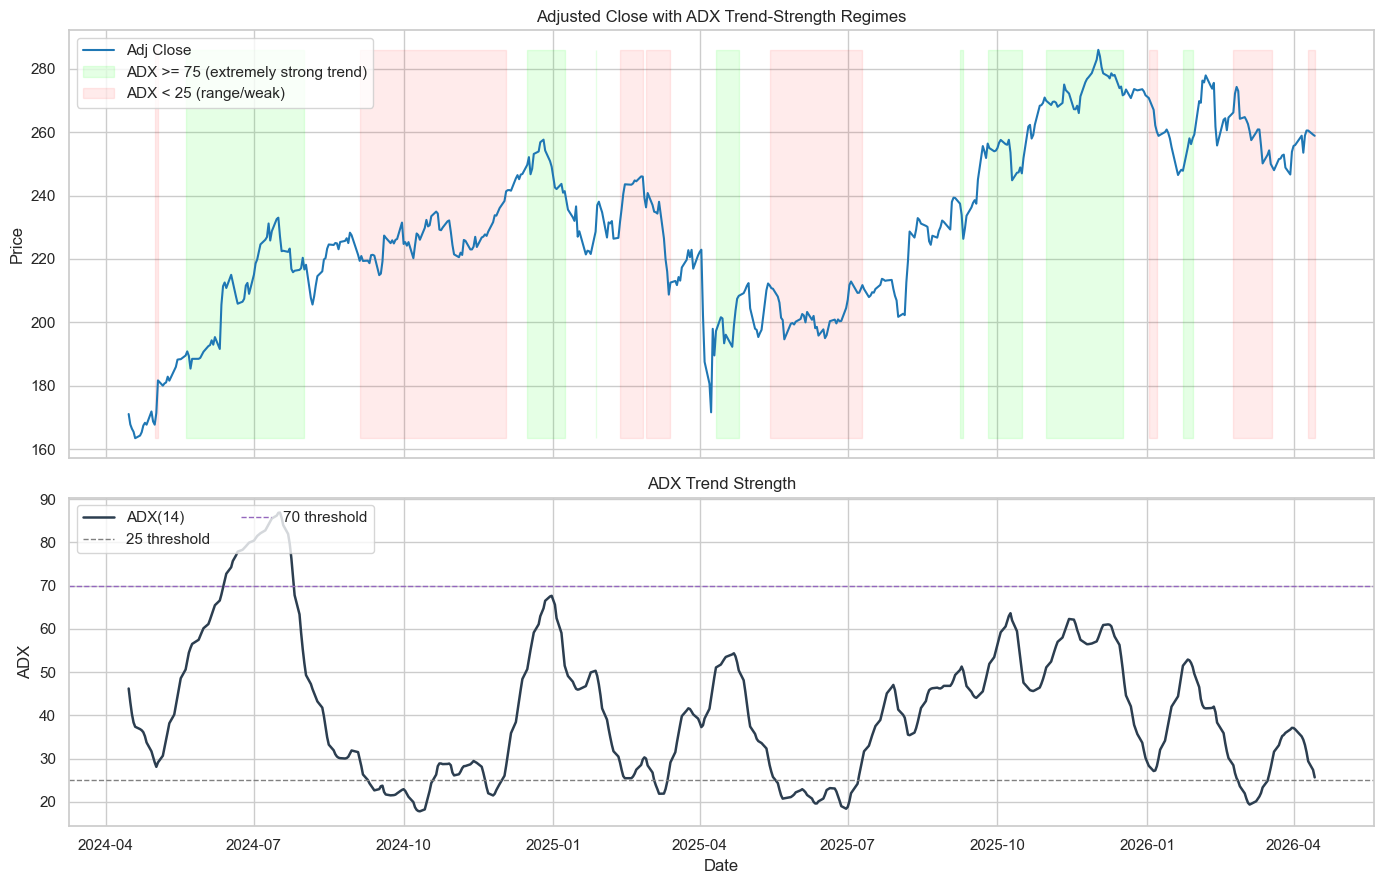

In [22]:
# ADX visualization (Investopedia-style strength interpretation)
# ADX is non-directional: it measures trend strength, not up/down direction.
# Common interpretation: <20 weak/range, >25 stronger trend, >50 very strong trend.
df_curr = trim(df, 2)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})

# Panel 1: Price with ADX regime shading
axes[0].plot(df_curr.index, df_curr["Adj Close"], color="#1f77b4", linewidth=1.5, label="Adj Close")

strong = df_curr["adx_14"] >= 50
weak = df_curr["adx_14"] < 30

axes[0].fill_between(df_curr.index, df_curr["Adj Close"].min(), df_curr["Adj Close"].max(), where=strong, color="#00ff00", alpha=0.10, label="ADX >= 75 (extremely strong trend)")
axes[0].fill_between(df_curr.index, df_curr["Adj Close"].min(), df_curr["Adj Close"].max(), where=weak, color="#ff0000", alpha=0.08, label="ADX < 25 (range/weak)")
axes[0].set_title("Adjusted Close with ADX Trend-Strength Regimes")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")

# Panel 2: ADX with thresholds
axes[1].plot(df_curr.index, df_curr["adx_14"], color="#2c3e50", linewidth=1.8, label="ADX(14)")
axes[1].axhline(25, linestyle="--", color="gray", linewidth=1, label="25 threshold")
axes[1].axhline(70, linestyle="--", color="#9467bd", linewidth=1, label="70 threshold")
axes[1].set_title("ADX Trend Strength")
axes[1].set_ylabel("ADX")
axes[1].set_xlabel("Date")
axes[1].legend(loc="upper left", ncol=2)

plt.tight_layout()
plt.show()

In [27]:
# Report-friendly ADX regime summary table
regime = pd.cut(df_curr["adx_14"], bins=[-np.inf, 25, 50, 75, np.inf], labels=["<25 weak", "25-50 strong", "50-75 very strong", ">75 extremely strong"])
regime_summary = (
    df_curr.assign(adx_regime=regime)
      .groupby("adx_regime", observed=False)
      .agg(
          observations=("target_ret_1d_pct", "size"),
          mean_return_pct=("target_ret_1d_pct", "mean"),
          median_return_pct=("target_ret_1d_pct", "median"),
          min_return_pct=("target_ret_1d_pct", "min"),
          max_return_pct=("target_ret_1d_pct", "max"),

      )
      .round(4)
)
regime_summary

,observations,mean_return_pct,median_return_pct,min_return_pct,max_return_pct
adx_regime,,,,,
<25 weak,88,-0.06,0.11,-4.85,3.71
25-50 strong,278,0.14,0.11,-9.25,15.33
50-75 very strong,110,0.16,0.19,-3.89,7.26
>75 extremely strong,25,0.07,0.38,-2.88,2.91


### RSI vs Price (Oversold/Overbought) Insight

This section plots Apple’s adjusted close alongside RSI(14), highlighting oversold windows (RSI < 20) and marking the overbought threshold (RSI > 70) to visualize momentum extremes.

#### Insights

After RSI enters the oversold zone (e.g., RSI < 20), Apple’s price often rebounds in the following periods, consistent with short-term mean reversion after sharp selloffs.

Plus, Apple spends more time in the overbought region (RSI > 70) and tends to remain there longer than it does in oversold conditions, suggesting sustained bullish momentum and overall stock strength.

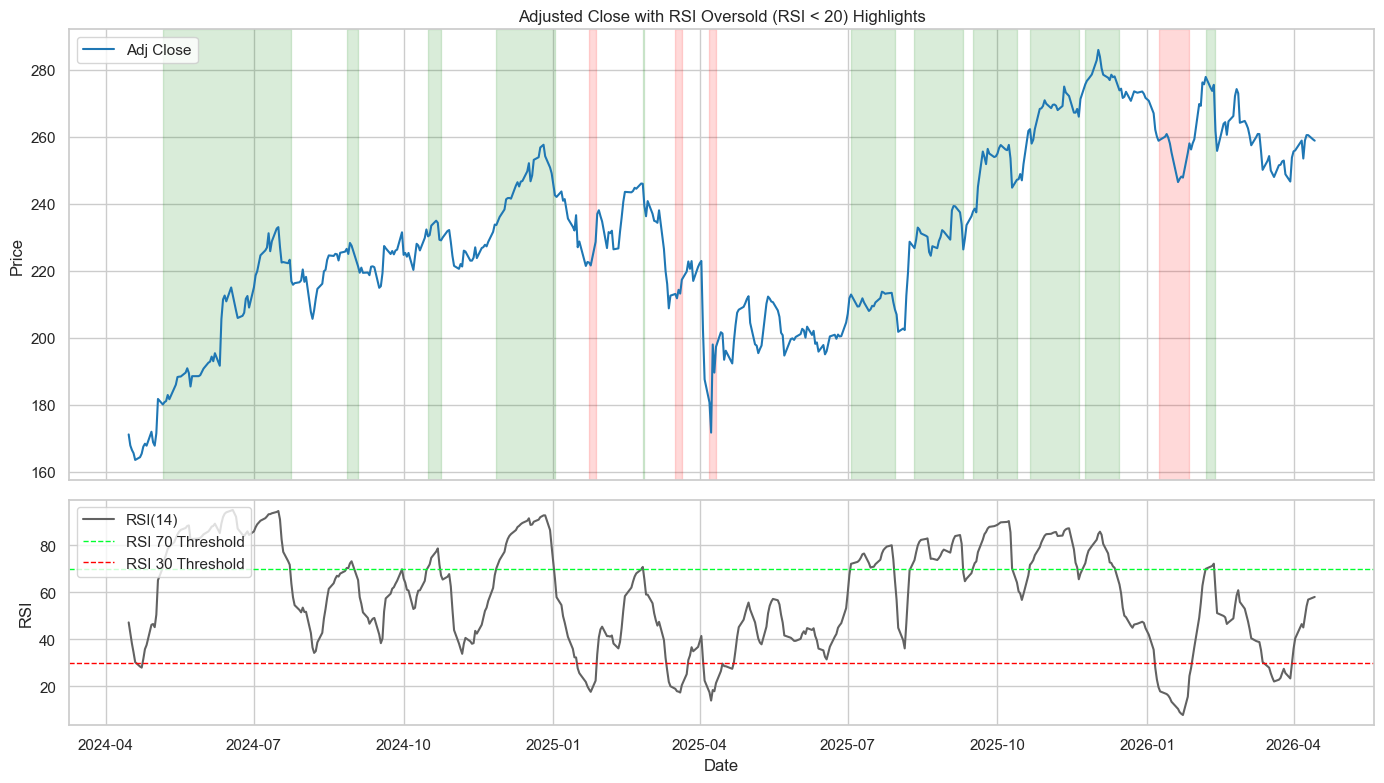

In [24]:
# RSI vs price with overbought highlight (RSI > 70)
df_curr = trim(df, 2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(df_curr.index, df_curr["Adj Close"], color="#1f77b4", label="Adj Close")
axes[0].set_title("Adjusted Close with RSI Oversold (RSI < 20) Highlights")
axes[0].set_ylabel("Price")

rsi_oversold = df_curr["rsi_14"] < 20
rsi_overbought = df_curr["rsi_14"] > 70
if rsi_oversold.any():
    start = None
    for idx, flag in rsi_oversold.items():
        if flag and start is None:
            start = idx
        elif not flag and start is not None:
            axes[0].axvspan(start, idx, color="red", alpha=0.15)
            start = None
    if start is not None:
        axes[0].axvspan(start, df_curr.index[-1], color="red", alpha=0.15)

if rsi_overbought.any():
    start = None
    for idx, flag in rsi_overbought.items():
        if flag and start is None:
            start = idx
        elif not flag and start is not None:
            axes[0].axvspan(start, idx, color="green", alpha=0.15)
            start = None
    if start is not None:
        axes[0].axvspan(start, df_curr.index[-1], color="green", alpha=0.15)

axes[1].plot(df_curr.index, df_curr["rsi_14"], color="#626262", label="RSI(14)")
axes[1].axhline(70, linestyle="--", color="#00FF2F", linewidth=1, label="RSI 70 Threshold")
axes[1].axhline(30, linestyle="--", color="#ff0000", linewidth=1, label="RSI 30 Threshold")
axes[1].set_ylabel("RSI")
axes[1].set_xlabel("Date")

axes[0].legend(loc="upper left")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

### MACD Histogram vs Next-Day Return (Quintile Analysis)

This section bins the MACD histogram into quintiles (from low to high) and uses a boxplot to compare the distribution of next-day returns across bins. This helps to assess whether MACD momentum is associated with stronger or weaker next-day performance.

`Q1` to `Q5` are **quintile bins** of your `MACD histogram` values:

- `Q1` = lowest 20% of MACD histogram values (most negative/weakest momentum)
- `Q5` = highest 20% (most positive/strongest momentum)


**Insights**

Across Q1 to Q5, the main differences show up in the tails: Q1 has an unusually large positive outlier (around +15%), while Q4 shows some of the most extreme negative outliers (around -9%). Plus, even the mean return of Q5 is notably negative, despite Q5 representing the most positive momentum. 

Because the MACD histogram is an “acceleration” measure, a high value can reflect strengthening momentum, but it can also appear after an extended run when price is already very high, and a reversal in stock price is to be expected. The opposite is true too, for overly negative values.

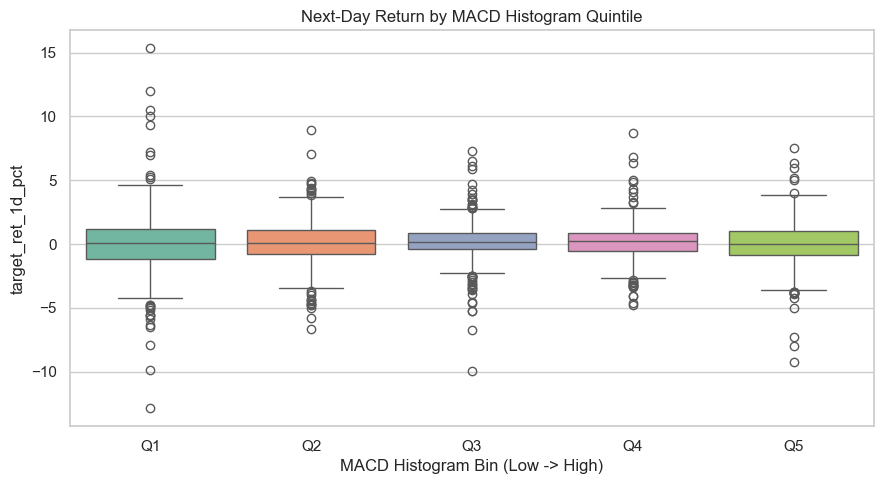

,observations,mean_return_pct,min_return_pct,max_return_pct
macd_bin,,,,
Q1,496,0.02,-12.86,15.33
Q2,496,0.13,-6.63,8.90
Q3,495,0.17,-9.96,7.26
Q4,496,0.21,-4.80,8.72
Q5,496,0.05,-9.25,7.56


In [25]:
# MACD relationship with next-day return (quintile boxplot only)

macd_bins = pd.qcut(df["macd_hist_12_26_9"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop")

plot_df = df[["target_ret_1d_pct"]].copy()
plot_df["macd_bin"] = macd_bins

plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x="macd_bin", y="target_ret_1d_pct", hue="macd_bin", palette="Set2", legend=False)
plt.title("Next-Day Return by MACD Histogram Quintile")
plt.xlabel("MACD Histogram Bin (Low -> High)")
plt.ylabel("target_ret_1d_pct")
plt.tight_layout()
plt.show()

# Robust labels in case qcut drops duplicate edges
q_labels = [f"Q{i+1}" for i in range(macd_bins.cat.categories.size)]
macd_bin = macd_bins.cat.rename_categories(q_labels)

macd_summary = (
    df.assign(macd_bin=macd_bin)
      .groupby("macd_bin", observed=False)
      .agg(
          observations=("target_ret_1d_pct", "size"),
          mean_return_pct=("target_ret_1d_pct", "mean"),
          min_return_pct=("target_ret_1d_pct", "min"),
          max_return_pct=("target_ret_1d_pct", "max"),
      )
      .round(4)
)

macd_summary


### Bollinger Bands and Bandwidth (Volatility Visualization)

This section plots Bollinger Bands (20-day mean with ±2 standard deviations) against the adjusted close to show when price moves toward statistical extremes, and it tracks Bollinger Bandwidth over time to highlight periods of expanding vs contracting volatility (potential breakouts vs consolidations).

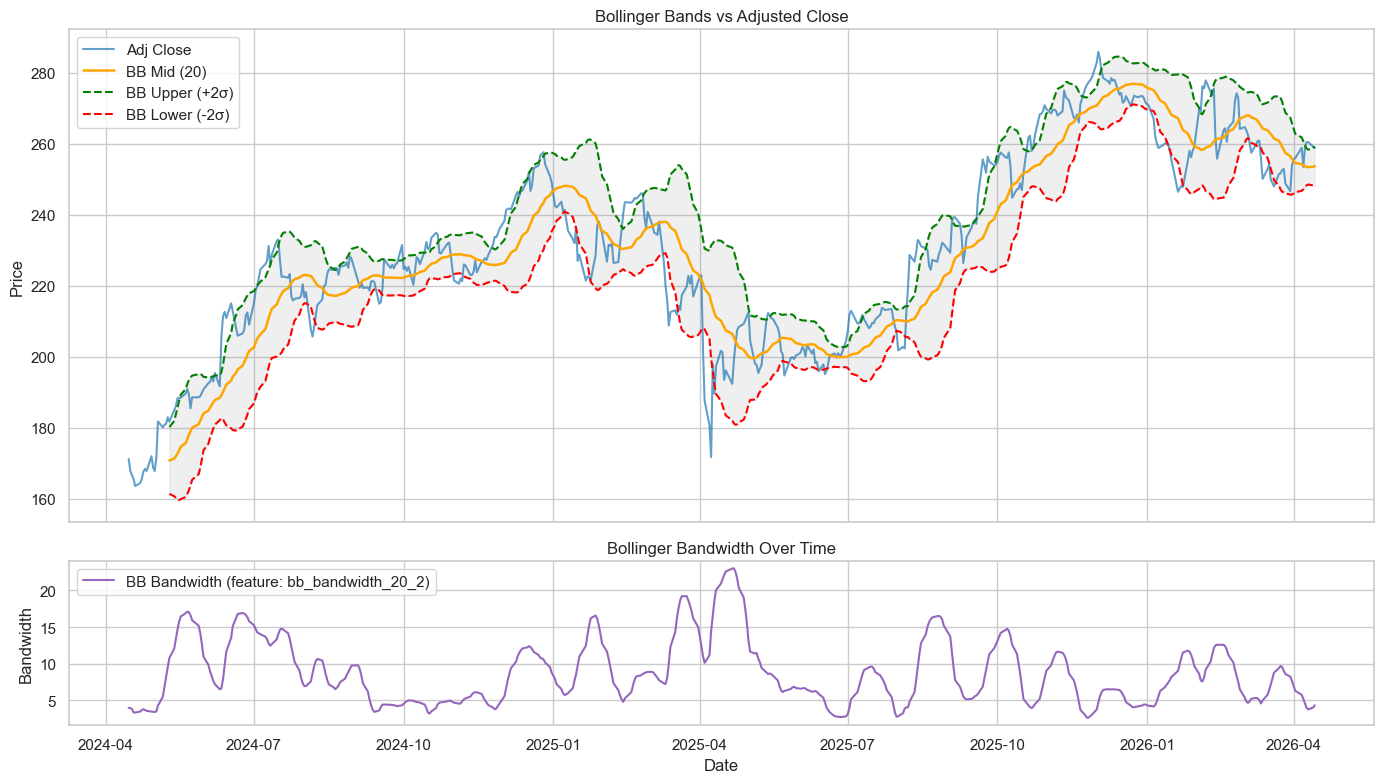

In [26]:
# Bollinger Bands (20,2) against adjusted close + Bandwidth
df_curr = trim(df, 2)

rolling_mid = df_curr["adj_close_smooth"].rolling(window=20).mean()
rolling_std = df_curr["adj_close_smooth"].rolling(window=20).std()
bb_upper = rolling_mid + 2 * rolling_std
bb_lower = rolling_mid - 2 * rolling_std
bb_width = bb_upper - bb_lower

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# Price + bands
ax = axes[0]
ax.plot(df_curr.index, df_curr["Adj Close"], label="Adj Close", color="#1f77b4", alpha=0.7)
ax.plot(df_curr.index, rolling_mid, label="BB Mid (20)", color="orange", linewidth=1.8)
ax.plot(df_curr.index, bb_upper, label="BB Upper (+2σ)", color="green", linestyle="--")
ax.plot(df_curr.index, bb_lower, label="BB Lower (-2σ)", color="red", linestyle="--")
ax.fill_between(df_curr.index, bb_lower, bb_upper, color="gray", alpha=0.12)
ax.set_title("Bollinger Bands vs Adjusted Close")
ax.set_ylabel("Price")
ax.legend(loc="upper left")

# Bandwidth
ax2 = axes[1]
if "bb_bandwidth_20_2" in df_curr.columns:
    bandwidth = df_curr["bb_bandwidth_20_2"]
    ax2.plot(df_curr.index, bandwidth, label="BB Bandwidth (feature: bb_bandwidth_20_2)", color="#9467bd")
else:
    bandwidth = (bb_width / rolling_mid) * 100
    ax2.plot(df_curr.index, bandwidth, label="BB Bandwidth (%): (Upper-Lower)/Mid * 100", color="#9467bd")

ax2.set_title("Bollinger Bandwidth Over Time")
ax2.set_xlabel("Date")
ax2.set_ylabel("Bandwidth")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 7) EDA Interpretation Notes for Report Writing

Use this section to summarize Chapter 3 insights in your report:

1. Statistical profile:
   - Describe central tendency and dispersion of `target_ret_1d_pct`.
   - Mention any visible skewness and outliers.

2. Feature behavior:
   - Highlight which indicators are stable vs highly volatile.
   - Note any non-Gaussian feature distributions.

3. Correlation findings:
   - Report strongest positive/negative feature-target relationships.
   - Discuss whether correlations are weak/moderate/strong and implications for linear regression.

4. Regime insights:
   - Explain how target distribution differs between trending and ranging periods (ADX regimes).

5. Model implication:
   - If relationships appear weakly linear or regime-dependent, note this as motivation for comparing additional models in later chapters.
